# Ray API sketch

This notebook is a user-facing sketch of the first-pass ray and imaging API.

The camera, domain-seeding, traversal, and midpoint-rendering sections below are real code.

Design intent:
- exact per-cell `t_enter` and `t_exit` in physical `xyz`
- traversal operates directly on adaptive octree cells
- spherical trees still trace rays in `xyz`
- image formation stays layered above traversal


## Build the existing octree pieces

The new ray layer sits on top of the current `Octree` and `OctreeInterpolator`.


In [1]:
from batread import Dataset
import numpy as np

from batcamp import Octree
from batcamp import OctreeInterpolator

ds = Dataset.from_file("../sample_data/3d__var_1_n00000000.plt")

tree = Octree(
    points=ds[["X [R]", "Y [R]", "Z [R]"]],
    corners=ds.corners,
)

rho = ds["Rho [g/cm^3]"]
interp = OctreeInterpolator(tree, values=rho)

tree, interp


(<batcamp.octree.Octree at 0x10ccaf8c0>,
 <batcamp.interpolator.OctreeInterpolator at 0x11d608d70>)

## Define a camera

For the first pass, the camera surface is just one function returning two arrays:

- `origins`
- `directions`

Both have shape `(ny, nx, 3)`.


In [2]:
from batcamp import camera_rays

camera_origin = np.array([-60.0, 0.0, 0.0])
camera_target = np.array([0.0, 0.0, 0.0])
camera_up = np.array([0.0, 0.0, 1.0])

origins, directions = camera_rays(
    origin=camera_origin,
    target=camera_target,
    up=camera_up,
    nx=12,
    ny=10,
    width=48.0,
    height=36.0,
    projection="parallel",
)

origins.shape, directions.shape


((10, 12, 3), (10, 12, 3))

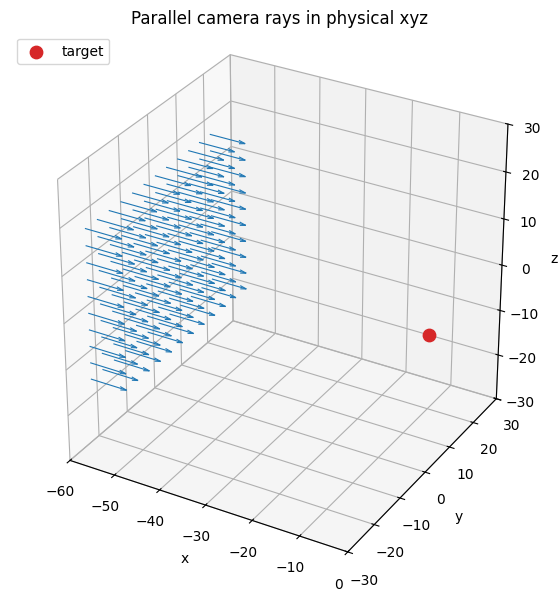

In [3]:
import matplotlib.pyplot as plt

tail = 8.0
origins_flat = origins.reshape(-1, 3)
directions_flat = directions.reshape(-1, 3)
tips_flat = origins_flat + tail * directions_flat

fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection="3d")
ax.quiver(
    origins_flat[:, 0],
    origins_flat[:, 1],
    origins_flat[:, 2],
    directions_flat[:, 0],
    directions_flat[:, 1],
    directions_flat[:, 2],
    length=tail,
    normalize=False,
    arrow_length_ratio=0.18,
    linewidth=0.8,
    color="tab:blue",
)
ax.scatter(
    [camera_target[0]],
    [camera_target[1]],
    [camera_target[2]],
    color="tab:red",
    s=80,
    label="target",
)

all_points = np.vstack((origins_flat, tips_flat, camera_target.reshape(1, 3)))
mins = all_points.min(axis=0)
maxs = all_points.max(axis=0)
span = np.maximum(maxs - mins, 1.0)
center = 0.5 * (mins + maxs)
radius = 0.5 * float(np.max(span))
ax.set_xlim(center[0] - radius, center[0] + radius)
ax.set_ylim(center[1] - radius, center[1] + radius)
ax.set_zlim(center[2] - radius, center[2] + radius)
ax.set_box_aspect((1.0, 1.0, 1.0))
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.set_title("Parallel camera rays in physical xyz")
ax.legend(loc="upper left")
plt.show()


## Seed rays inside the octree domain

The first implemented tracer pass only returns one seed point per ray inside the global octree domain.

For the spherical sample tree above, this uses the front visible shell only: once a forward ray hits the opaque inner boundary, the ray is finished.


In [4]:
from batcamp import OctreeRayTracer

tracer = OctreeRayTracer(tree)
seed_xyz = tracer.seed_domain(origins, directions, t_min=0.0, t_max=np.inf)

seed_xyz.shape


(10, 12, 3)

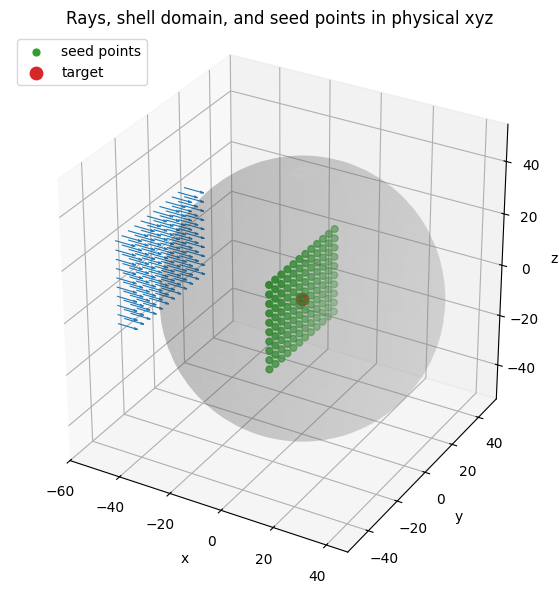

In [5]:
rpa_lo, rpa_hi = tree.domain_bounds(coord="rpa")
r_inner = float(rpa_lo[0])
r_outer = float(rpa_hi[0])

seed_flat = seed_xyz.reshape(-1, 3)
seed_mask = np.isfinite(seed_flat).all(axis=1)

azimuth = np.linspace(0.0, 2.0 * np.pi, 80)
polar = np.linspace(0.0, np.pi, 40)
azimuth_grid, polar_grid = np.meshgrid(azimuth, polar, indexing="xy")

def sphere_xyz(radius):
    x = radius * np.sin(polar_grid) * np.cos(azimuth_grid)
    y = radius * np.sin(polar_grid) * np.sin(azimuth_grid)
    z = radius * np.cos(polar_grid)
    return x, y, z

outer_x, outer_y, outer_z = sphere_xyz(r_outer)
inner_x, inner_y, inner_z = sphere_xyz(r_inner)

fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection="3d")
ax.plot_surface(outer_x, outer_y, outer_z, color="tab:gray", alpha=0.15, linewidth=0.0)
ax.plot_surface(inner_x, inner_y, inner_z, color="tab:orange", alpha=0.45, linewidth=0.0)
ax.quiver(
    origins_flat[:, 0],
    origins_flat[:, 1],
    origins_flat[:, 2],
    directions_flat[:, 0],
    directions_flat[:, 1],
    directions_flat[:, 2],
    length=tail,
    normalize=False,
    arrow_length_ratio=0.18,
    linewidth=0.8,
    color="tab:blue",
)
ax.scatter(
    seed_flat[seed_mask, 0],
    seed_flat[seed_mask, 1],
    seed_flat[seed_mask, 2],
    color="tab:green",
    s=24,
    label="seed points",
)
ax.scatter(
    [camera_target[0]],
    [camera_target[1]],
    [camera_target[2]],
    color="tab:red",
    s=80,
    label="target",
)

sphere_points = np.column_stack((outer_x.reshape(-1), outer_y.reshape(-1), outer_z.reshape(-1)))
all_points = np.vstack((origins_flat, tips_flat, seed_flat[seed_mask], sphere_points))
mins = all_points.min(axis=0)
maxs = all_points.max(axis=0)
span = np.maximum(maxs - mins, 1.0)
center = 0.5 * (mins + maxs)
radius = 0.5 * float(np.max(span))
ax.set_xlim(center[0] - radius, center[0] + radius)
ax.set_ylim(center[1] - radius, center[1] + radius)
ax.set_zlim(center[2] - radius, center[2] + radius)
ax.set_box_aspect((1.0, 1.0, 1.0))
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.set_title("Rays, shell domain, and seed points in physical xyz")
ax.legend(loc="upper left")
plt.show()


## Trace one spherical ray

The public tracer can now trace one seeded spherical ray through the planarized cell geometry.

This first pass uses seeded traversal and stops at the opaque inner boundary.


In [6]:
single_origin = np.array([-60.0, 0.5, 0.25], dtype=float)
single_direction = np.array([1.0, 0.0, 0.0], dtype=float)
single_seed = tracer.seed_domain(single_origin, single_direction)
single_segments = tracer.trace(single_origin, single_direction, seed_xyz=single_seed)

leaf_ids = single_segments.cell_ids
t_enter = single_segments.t_enter
t_exit = single_segments.t_exit
segment_length = single_segments.segment_length

single_seed, leaf_ids[:6], t_enter[:6], t_exit[:6], segment_length[:6]


OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


(array([[-24.49362194,   0.5       ,   0.25      ]]),
 array([5687, 5686, 5685, 5684, 5683, 5682]),
 array([12.07386834, 22.36407904, 30.44827931, 36.79939909, 41.78896761,
        45.70886953]),
 array([22.36407904, 30.44827931, 36.79939909, 41.78896761, 45.70886953,
        48.78842853]),
 array([10.2902107 ,  8.08420027,  6.35111978,  4.98956851,  3.91990192,
         3.079559  ]))

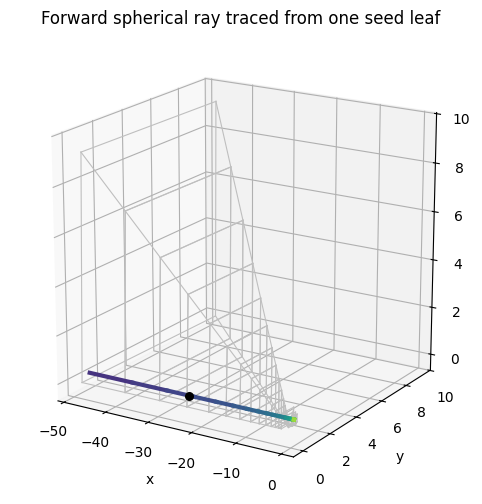

In [7]:
corner_bits = np.array(
    [
        [0, 1, 0],
        [1, 1, 0],
        [1, 1, 1],
        [0, 1, 1],
        [0, 0, 0],
        [1, 0, 0],
        [1, 0, 1],
        [0, 0, 1],
    ],
    dtype=np.int8,
)
edge_pairs = []
for i in range(8):
    for j in range(i + 1, 8):
        if np.count_nonzero(corner_bits[i] != corner_bits[j]) == 1:
            edge_pairs.append((i, j))

fig = plt.figure(figsize=(9, 6))
ax = fig.add_subplot(projection="3d")
colors = plt.cm.viridis(np.linspace(0.15, 0.85, leaf_ids.size))

for cell_id in leaf_ids:
    cell_xyz = tree.cell_points(int(cell_id))
    for i0, i1 in edge_pairs:
        edge_xyz = cell_xyz[[i0, i1]]
        ax.plot(edge_xyz[:, 0], edge_xyz[:, 1], edge_xyz[:, 2], color="0.75", linewidth=0.8)

ray_t = np.array([t_enter[0], t_exit[-1]], dtype=float)
ray_xyz = single_origin[None, :] + ray_t[:, None] * single_direction[None, :]
ax.plot(ray_xyz[:, 0], ray_xyz[:, 1], ray_xyz[:, 2], color="black", linewidth=1.2, linestyle="--")
ax.scatter(single_seed[0, 0], single_seed[0, 1], single_seed[0, 2], color="black", s=30)

for color, t0, t1 in zip(colors, t_enter, t_exit):
    seg_t = np.array([t0, t1], dtype=float)
    seg_xyz = single_origin[None, :] + seg_t[:, None] * single_direction[None, :]
    ax.plot(seg_xyz[:, 0], seg_xyz[:, 1], seg_xyz[:, 2], color=color, linewidth=3)

ax.set_title("Forward spherical ray traced from one seed leaf")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.set_box_aspect((1.0, 1.0, 1.0))
ax.view_init(elev=18, azim=-58)
plt.show()


## Trace adaptive octree segments

The first public traversal call returns packed per-ray cell segments:


In [8]:
from batcamp import render_midpoint_image

segments = tracer.trace(origins, directions, seed_xyz=seed_xyz, t_min=0.0, t_max=np.inf)

segments.ray_offsets.shape, segments.cell_ids.shape, segments.t_enter.shape, segments.t_exit.shape


((121,), (3384,), (3384,), (3384,))

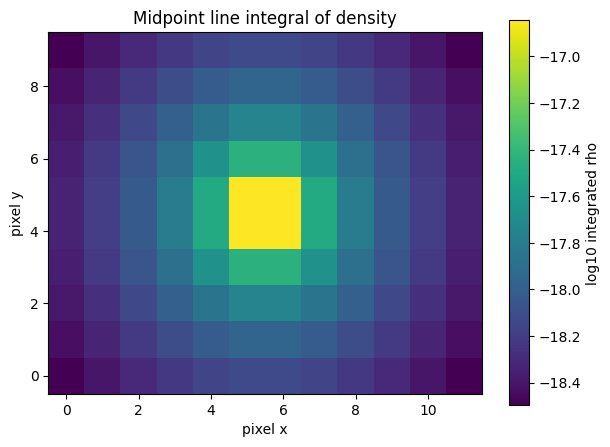

((10, 12), 3.175674702049804e-19, 1.4279572002594696e-17)

In [9]:
image = render_midpoint_image(interp, origins, directions, segments)
log_image = np.log10(np.maximum(image, np.finfo(float).tiny))

fig, ax = plt.subplots(figsize=(7, 5))
mesh = ax.pcolormesh(log_image, shading="nearest")
ax.set_title("Midpoint line integral of density")
ax.set_xlabel("pixel x")
ax.set_ylabel("pixel y")
ax.set_aspect("equal")
fig.colorbar(mesh, ax=ax, label="log10 integrated rho")
plt.show()

image.shape, float(np.nanmin(image)), float(np.nanmax(image))
